# 차량 가격 적정성 분류 모델 분석

Regression 노트북에서 생성한 `price_class`를 target으로 차량 가격 적정성을 분류한다.

**분류 기준 (gap_ratio = (실제가격 − 예측가격) / 예측가격)**

| 클래스 | 조건 | 의미 |
|--------|------|------|
| 0 | gap_ratio < -0.10 | Underpriced (시세보다 저렴) |
| 1 | -0.10 ≤ gap_ratio ≤ 0.10 | Fairly Priced (시세 적정) |
| 2 | gap_ratio > 0.10 | Overpriced (시세보다 비쌈) |

**이 노트북의 핵심 과제**
- 클래스 불균형 문제: Fairly Priced가 다수 → 모델이 항상 1만 예측할 위험
- `class_weight='balanced'` 로 소수 클래스(Underpriced/Overpriced) recall 개선
- Stratified 5-Fold CV로 하이퍼파라미터 탐색
- Baseline(MSRP 미포함) vs Enhanced(MSRP 포함) 비교


## Step 1. 라이브러리 임포트

In [ ]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid', palette='muted')

import matplotlib.pyplot as plt

plt.rcParams['axes.unicode_minus'] = False

CLASS_NAMES  = ['Underpriced', 'Fairly Priced', 'Overpriced']
COLOR_BASE   = '#4C72B0'
COLOR_ENH    = '#DD8452'

print("Libraries loaded successfully")


Libraries loaded successfully


## Step 2. 전처리 + Regression 결과 이어받기

Regression 노트북에서 생성한 `df_final_out`(price_class 포함)을 직접 사용한다.
별도 CSV 로드나 재인코딩 없이 메모리 변수를 그대로 이어받는다.

**이어받는 변수**

| 변수 | 내용 |
|------|------|
| `df_final_out` | price_class, predicted_price, gap_ratio 포함 |
| `X_train`, `X_test` | 전처리 완료 (OHE + Target Encoding + StandardScaler) |
| `y_train_log`, `y_test_log` | log 변환 타겟 (참고용) |


In [ ]:
# Verify preprocessing + Regression results
print("=" * 55)
print("  Loaded Data Check")
print("=" * 55)
print(f"  df_final_out : {df_final_out.shape}")
print(f"  price_class distribution:")
dist = df_final_out['price_class'].value_counts().sort_index()
for i, name in enumerate(CLASS_NAMES):
    cnt = dist.get(i, 0)
    print(f"    {i} {name:15s}: {cnt:>5} ({cnt/len(df_final_out)*100:.1f}%)")
print()
print(f"  X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"  Feature list: {list(X_train.columns)}")


  Loaded Data Check
  df_final_out : (5000, 54)
  price_class distribution:
    0 Underpriced    :  1650 (33.0%)
    1 Fairly Priced  :  1700 (34.0%)
    2 Overpriced     :  1650 (33.0%)

  X_train: (4000, 50)  |  X_test: (1000, 50)
  Feature list: ['condition', 'odometer', 'vehicle_age', 'estimate_msrp', 'cylinders_12', 'cylinders_3', 'cylinders_4', 'cylinders_5', 'cylinders_6', 'cylinders_8', 'cylinders_other', 'manufacturer_chevrolet', 'manufacturer_dodge', 'manufacturer_ford', 'manufacturer_gmc', 'manufacturer_honda', 'manufacturer_hyundai', 'manufacturer_jeep', 'manufacturer_kia', 'manufacturer_lexus', 'manufacturer_mercedes-benz', 'manufacturer_nissan', 'manufacturer_other', 'manufacturer_ram', 'manufacturer_subaru', 'manufacturer_toyota', 'manufacturer_volkswagen', 'fuel_electric', 'fuel_gas', 'fuel_hybrid', 'fuel_other', 'transmission_manual', 'transmission_other', 'type_coupe', 'type_other', 'type_pickup', 'type_sedan', 'type_truck', 'title_status_lien', 'title_status_rebuilt'

## Step 3. 클래스 분포 확인

클래스 불균형 여부를 먼저 파악한다.
Fairly Priced가 압도적으로 많으면 → 모델이 항상 1(Fairly Priced)만 예측해도
높은 Accuracy가 나오는 **Accuracy Paradox** 발생 가능.
→ **F1-score(macro)와 소수 클래스 Recall을 핵심 지표로 사용**


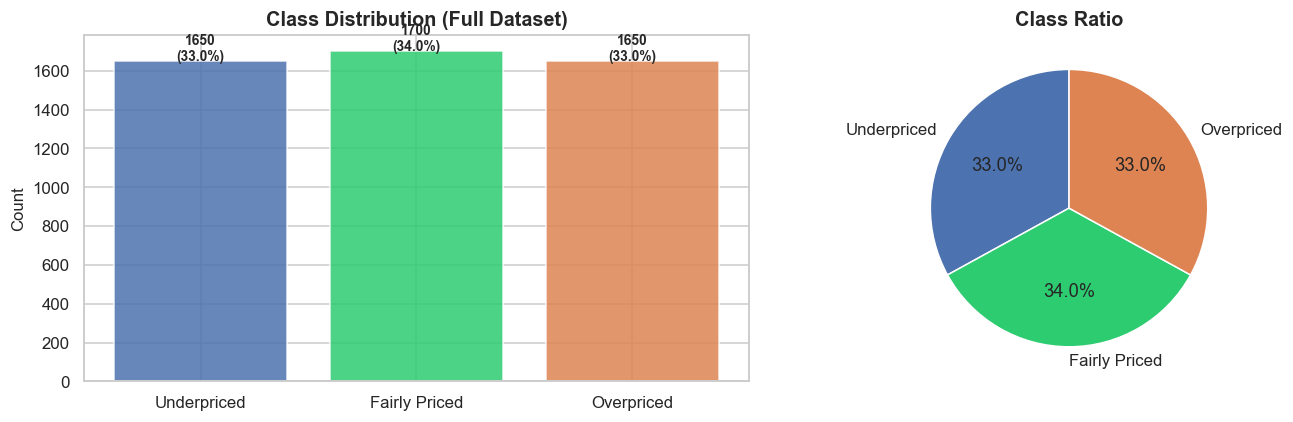

불균형 비율 (majority / minority): 1.0:1
가벼운 계급 불균형


In [ ]:
y_full = df_final_out['price_class']
dist   = y_full.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
ax = axes[0]
colors_cls = [COLOR_BASE, '#2ecc71', COLOR_ENH]
bars = ax.bar(CLASS_NAMES, [dist.get(i,0) for i in range(3)],
              color=colors_cls, alpha=0.85, edgecolor='white')
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Class Distribution (Full Dataset)', fontsize=13, fontweight='bold')
for bar, v in zip(bars, [dist.get(i,0) for i in range(3)]):
    ax.text(bar.get_x()+bar.get_width()/2, v+1,
            f'{v}\n({v/len(y_full)*100:.1f}%)',
            ha='center', fontsize=9, fontweight='bold')

# Pie chart
ax = axes[1]
ax.pie([dist.get(i,0) for i in range(3)], labels=CLASS_NAMES,
       colors=colors_cls, autopct='%1.1f%%', startangle=90,)
ax.set_title('Class Ratio', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Print imbalance level
majority = dist.max(); minority = dist.min()
print(f"불균형 비율 (majority / minority): {majority/minority:.1f}:1")
if majority/minority > 3:
    print("심각한 계급 불균형 → class_weight 적용 = balanced")
else:
    print("가벼운 계급 불균형")


## Step 4. Baseline / Enhanced 분기 + 타겟 설정

전처리 완료된 `X_train` / `X_test`에서 `estimate_msrp` 유무로 두 버전을 분기한다.

타겟(price_class)은 Regression 노트북의 Train/Test split 인덱스를 그대로 사용한다.


In [ ]:
# price_class target — using same index as Regression
y_train_cls = df_final_out.loc[X_train.index, 'price_class']
y_test_cls  = df_final_out.loc[X_test.index,  'price_class']

# Baseline / Enhanced split
X_train_base = X_train.drop(columns=['estimate_msrp'], errors='ignore').copy()
X_test_base  = X_test.drop(columns=['estimate_msrp'],  errors='ignore').copy()
X_train_enh  = X_train.copy()
X_test_enh   = X_test.copy()

print(f"Baseline  features: {X_train_base.shape[1]}")
print(f"Enhanced  features: {X_train_enh.shape[1]}")
print()
print(f"Train class distribution:")
for i, n in enumerate(CLASS_NAMES):
    cnt = (y_train_cls == i).sum()
    print(f"  {i} {n:15s}: {cnt} ({cnt/len(y_train_cls)*100:.1f}%)")
print(f"\nTest class distribution:")
for i, n in enumerate(CLASS_NAMES):
    cnt = (y_test_cls == i).sum()
    print(f"  {i} {n:15s}: {cnt} ({cnt/len(y_test_cls)*100:.1f}%)")


Baseline  features: 49
Enhanced  features: 50

Train class distribution:
  0 Underpriced    : 1306 (32.6%)
  1 Fairly Priced  : 1365 (34.1%)
  2 Overpriced     : 1329 (33.2%)

Test class distribution:
  0 Underpriced    : 344 (34.4%)
  1 Fairly Priced  : 335 (33.5%)
  2 Overpriced     : 321 (32.1%)


## Step 5. 모델 정의

**class_weight='balanced' 적용 이유**

클래스 불균형 상태에서 기본 모델은 다수 클래스(Fairly Priced)에 편향되어
Underpriced/Overpriced를 거의 예측하지 못하는 문제가 발생한다.

`class_weight='balanced'`는 소수 클래스에 더 높은 가중치를 부여해
전체 Accuracy는 소폭 낮아지더라도 **소수 클래스 Recall을 개선**한다.

→ 중고차 가격 적정성 판단에서 저평가/고평가를 놓치는 것이 더 큰 문제이므로
   소수 클래스 Recall 개선이 실용적으로 더 중요하다.

**5개 분류 모델**

| 모델 | class_weight | 하이퍼파라미터 탐색 |
|------|-------------|-------------------|
| Logistic Regression | balanced | C (역규제강도) |
| Decision Tree | balanced | max_depth |
| KNN | — (미지원) | n_neighbors |
| SVM | balanced | C |
| Random Forest | balanced | n_estimators |


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Search grid: (model constructor, parameter candidates, parameter name)
SEARCH_GRID = {
    'Logistic Regression': (
        lambda c: LogisticRegression(C=c, class_weight='balanced',
                                     max_iter=3000, random_state=42),
        [0.01, 0.1, 1.0, 10, 100], 'C'
    ),
    'Decision Tree': (
        lambda d: DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                         random_state=42),
        [3, 5, 7, 10, None], 'max_depth'
    ),
    'KNN': (
        lambda k: KNeighborsClassifier(n_neighbors=k),
        [3, 5, 7, 11, 15, 21], 'k'
    ),
    'SVM': (
        lambda c: SVC(C=c, kernel='rbf', class_weight='balanced',
                      random_state=42),
        [0.1, 1.0, 10, 100], 'C'
    ),
    'Random Forest': (
        lambda n: RandomForestClassifier(n_estimators=n, max_depth=7,
                                         class_weight='balanced',
                                         random_state=42, n_jobs=-1),
        [50, 100, 200], 'n_estimators'
    ),
}

print("모델 검색 그리드 준비 완료")
print(f"Total {len(SEARCH_GRID)} models × Version A/B = {len(SEARCH_GRID)*2} experiments")


모델 검색 그리드 준비 완료
Total 5 models × Version A/B = 10 experiments


## Step 6. Stratified 5-Fold CV — 하이퍼파라미터 탐색

**평가 지표: F1-score (macro)**
- 클래스 불균형 상황에서 Accuracy는 다수 클래스에 의해 부풀려질 수 있음
- macro F1은 모든 클래스에 동등한 가중치 → 소수 클래스 성능 반영


In [ ]:
import time

def run_cv_search(X_tr, y_tr, version_label):
    results = {}
    print(f"\n{'='*62}")
    print(f"  CV SEARCH  |  {version_label}")
    print(f"{'='*62}")

    for model_name, (model_fn, params, param_name) in SEARCH_GRID.items():
        print(f"\n[{model_name}]  Search: {param_name}")
        best_param, best_cv, cv_log = None, -np.inf, []

        for p in params:
            t0 = time.time()
            cv_scores = cross_val_score(
                model_fn(p), X_tr, y_tr,
                cv=skf, scoring='f1_macro'
            )
            mean_cv = cv_scores.mean()
            cv_log.append((p, mean_cv, cv_scores.std()))
            flag = " ← best" if mean_cv > best_cv else ""
            print(f"  {param_name}={str(p):>6}  F1(macro): {mean_cv:.4f} "
                  f"(±{cv_scores.std():.4f})  {time.time()-t0:.1f}s{flag}")
            if mean_cv > best_cv:
                best_cv    = mean_cv
                best_param = p

        results[model_name] = {
            'best_param': best_param, 'best_cv': best_cv,
            'cv_log': cv_log, 'param_name': param_name,
        }
        print(f"  → Best {param_name}={best_param}  CV F1(macro): {best_cv:.4f}")
    return results

cv_results_A = run_cv_search(X_train_enh,  y_train_cls, "Enhanced  (estimate_msrp included)")
cv_results_B = run_cv_search(X_train_base, y_train_cls, "Baseline  (estimate_msrp excluded)")
print("\n검색 완료")



  CV SEARCH  |  Enhanced  (estimate_msrp included)

[Logistic Regression]  Search: C
  C=  0.01  F1(macro): 0.8195 (±0.0086)  0.3s ← best
  C=   0.1  F1(macro): 0.8374 (±0.0207)  0.5s ← best
  C=   1.0  F1(macro): 0.8462 (±0.0151)  0.7s ← best
  C=    10  F1(macro): 0.8487 (±0.0136)  1.0s ← best
  C=   100  F1(macro): 0.8490 (±0.0149)  1.2s ← best
  → Best C=100  CV F1(macro): 0.8490

[Decision Tree]  Search: max_depth
  max_depth=     3  F1(macro): 0.7918 (±0.0183)  0.1s ← best
  max_depth=     5  F1(macro): 0.8341 (±0.0125)  0.1s ← best
  max_depth=     7  F1(macro): 0.8421 (±0.0110)  0.2s ← best
  max_depth=    10  F1(macro): 0.8416 (±0.0095)  0.2s
  max_depth=  None  F1(macro): 0.8370 (±0.0095)  0.2s
  → Best max_depth=7  CV F1(macro): 0.8421

[KNN]  Search: k
  k=     3  F1(macro): 0.8229 (±0.0073)  3.3s ← best
  k=     5  F1(macro): 0.8237 (±0.0101)  0.1s ← best
  k=     7  F1(macro): 0.8297 (±0.0112)  0.1s ← best
  k=    11  F1(macro): 0.8274 (±0.0098)  0.2s
  k=    15  F1(macr

### Step 6-1. CV 탐색 결과 시각화

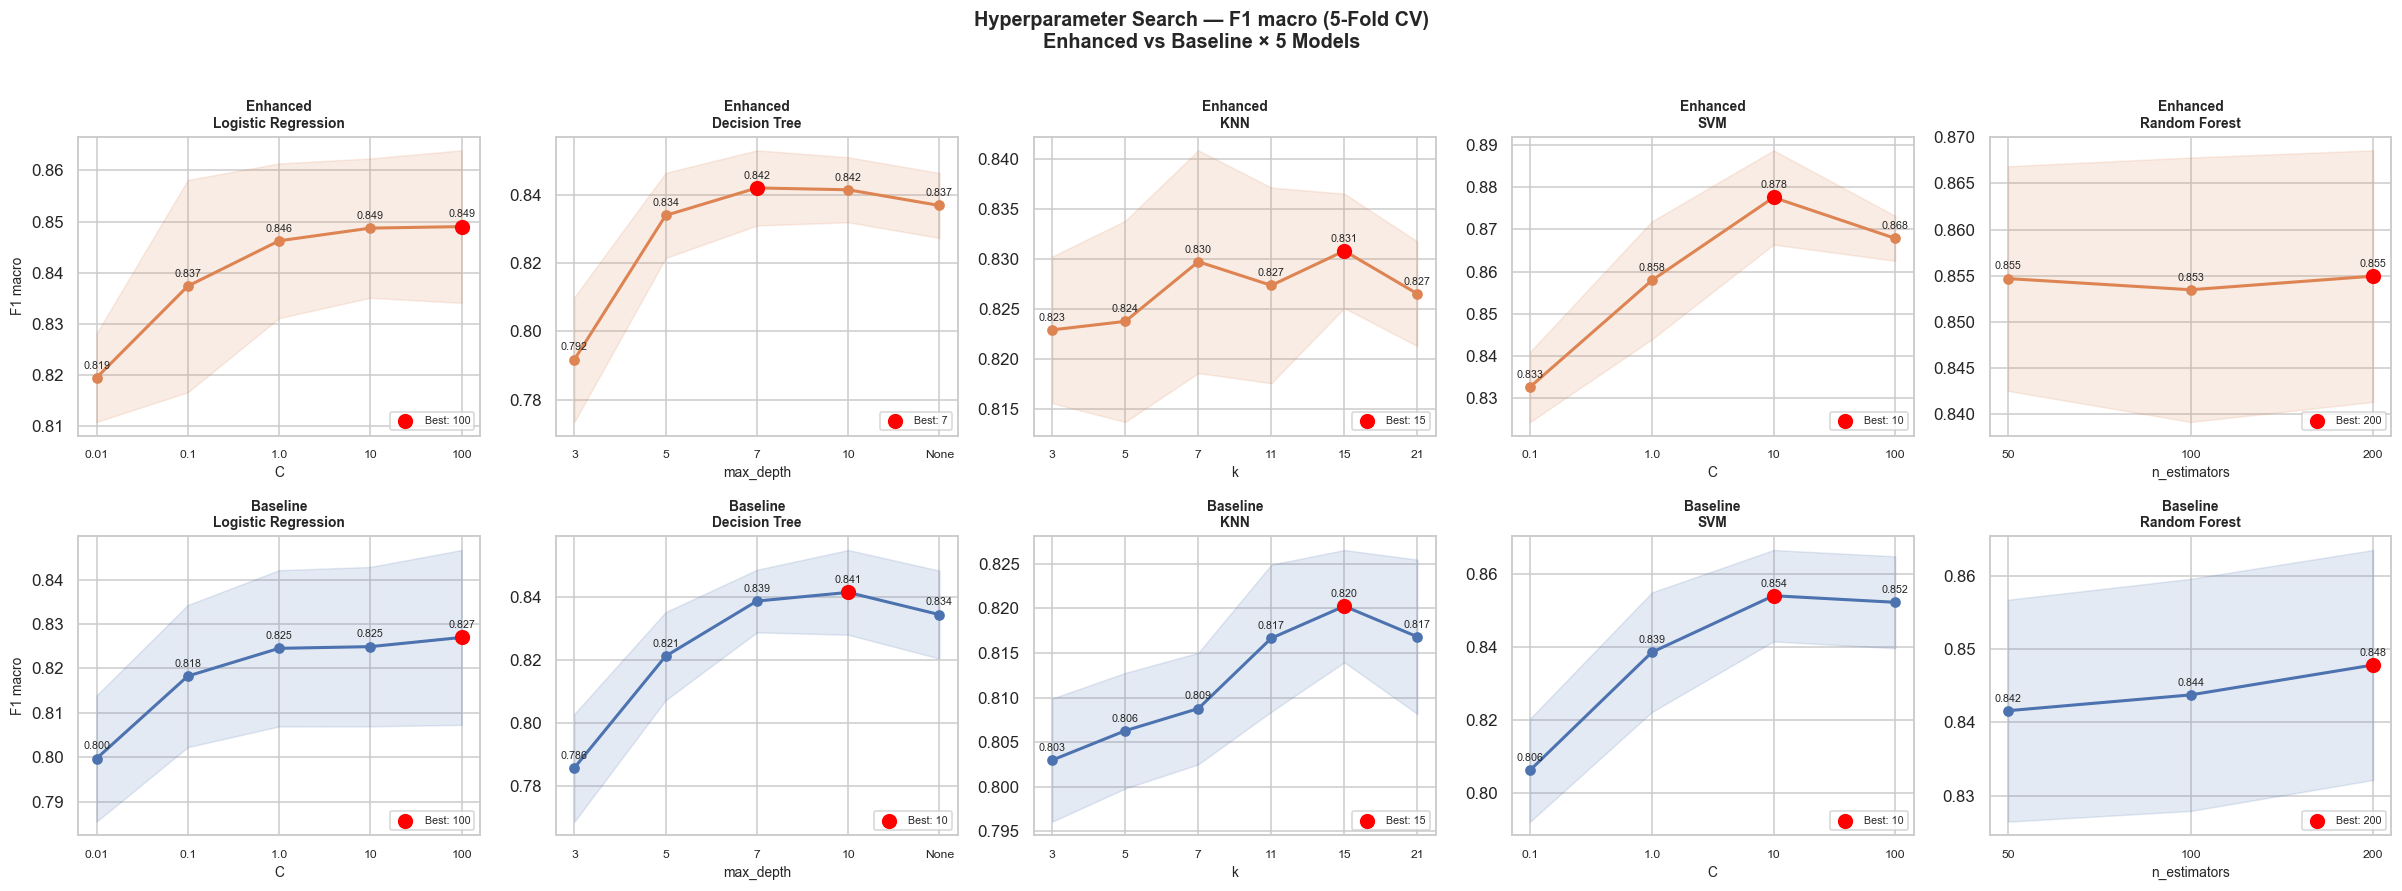

In [ ]:
model_names_list = list(SEARCH_GRID.keys())
fig, axes = plt.subplots(2, 5, figsize=(22, 8))

for row_idx, (cv_res, version, color) in enumerate([
    (cv_results_A, "Enhanced", COLOR_ENH),
    (cv_results_B, "Baseline", COLOR_BASE),
]):
    for col_idx, model_name in enumerate(model_names_list):
        ax   = axes[row_idx][col_idx]
        res  = cv_res[model_name]
        xlbl = [str(p) for p, _, _ in res['cv_log']]
        accs = [v for _, v, _ in res['cv_log']]
        stds = [s for _, _, s in res['cv_log']]
        best_idx = xlbl.index(str(res['best_param']))

        ax.plot(range(len(xlbl)), accs, marker='o', color=color,
                linewidth=2, markersize=6)
        ax.fill_between(range(len(xlbl)),
                        [a-s for a,s in zip(accs,stds)],
                        [a+s for a,s in zip(accs,stds)],
                        alpha=0.15, color=color)
        ax.scatter([best_idx], [accs[best_idx]], color='red', s=80,
                   zorder=5, label=f"Best: {res['best_param']}")
        ax.set_xticks(range(len(xlbl)))
        ax.set_xticklabels(xlbl, fontsize=8)
        ax.set_xlabel(res['param_name'], fontsize=9)
        ax.set_ylabel("F1 macro" if col_idx==0 else "", fontsize=9)
        ax.set_title(f"{version}\n{model_name}",
                     fontsize=9, fontweight='bold')
        ax.legend(fontsize=7, loc='lower right')
        for i, v in enumerate(accs):
            ax.annotate(f'{v:.3f}', (i, v), textcoords="offset points",
                        xytext=(0,6), ha='center', fontsize=7)

plt.suptitle("Hyperparameter Search — F1 macro (5-Fold CV)\nEnhanced vs Baseline × 5 Models",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Step 7. 최종 학습 및 Test 평가

In [ ]:
def fit_and_eval(cv_res, X_tr, y_tr, X_te, y_te, version_label):
    preds = {}
    print(f"\n{'='*62}")
    print(f"  TEST EVALUATION  |  {version_label}")
    print(f"{'='*62}")
    print(f"  {'Model':<22} {'Best Param':>16}  {'CV F1':>7}  {'Test Acc':>9}  {'F1 macro':>9}")
    print("  " + "-"*68)

    for model_name, (model_fn, _, param_name) in SEARCH_GRID.items():
        res   = cv_res[model_name]
        model = model_fn(res['best_param'])
        model.fit(X_tr, y_tr)
        y_pred     = model.predict(X_te)
        test_acc   = accuracy_score(y_te, y_pred)
        test_f1    = f1_score(y_te, y_pred, average='macro')
        param_str  = f"{param_name}={res['best_param']}"
        print(f"  {model_name:<22} {param_str:>16}  "
              f"{res['best_cv']:>7.4f}  {test_acc:>9.4f}  {test_f1:>9.4f}")
        preds[model_name] = {'model': model, 'y_pred': y_pred,
                             'test_acc': test_acc, 'test_f1': test_f1}
    return preds

preds_A = fit_and_eval(cv_results_A, X_train_enh,  y_train_cls,
                       X_test_enh,  y_test_cls, "Enhanced (estimate_msrp included)")
preds_B = fit_and_eval(cv_results_B, X_train_base, y_train_cls,
                       X_test_base, y_test_cls, "Baseline (estimate_msrp excluded)")



  TEST EVALUATION  |  Enhanced (estimate_msrp included)
  Model                        Best Param    CV F1   Test Acc   F1 macro
  --------------------------------------------------------------------
  Logistic Regression               C=100   0.8490     0.8340     0.8343
  Decision Tree               max_depth=7   0.8421     0.7810     0.7854
  KNN                                k=15   0.8308     0.8300     0.8295
  SVM                                C=10   0.8776     0.8690     0.8701
  Random Forest          n_estimators=200   0.8550     0.7940     0.7983

  TEST EVALUATION  |  Baseline (estimate_msrp excluded)
  Model                        Best Param    CV F1   Test Acc   F1 macro
  --------------------------------------------------------------------
  Logistic Regression               C=100   0.8270     0.8200     0.8201
  Decision Tree              max_depth=10   0.8414     0.7840     0.7883
  KNN                                k=15   0.8203     0.8180     0.8172
  SVM         

## Step 8. Confusion Matrix — 전체 모델 × Enhanced/Baseline

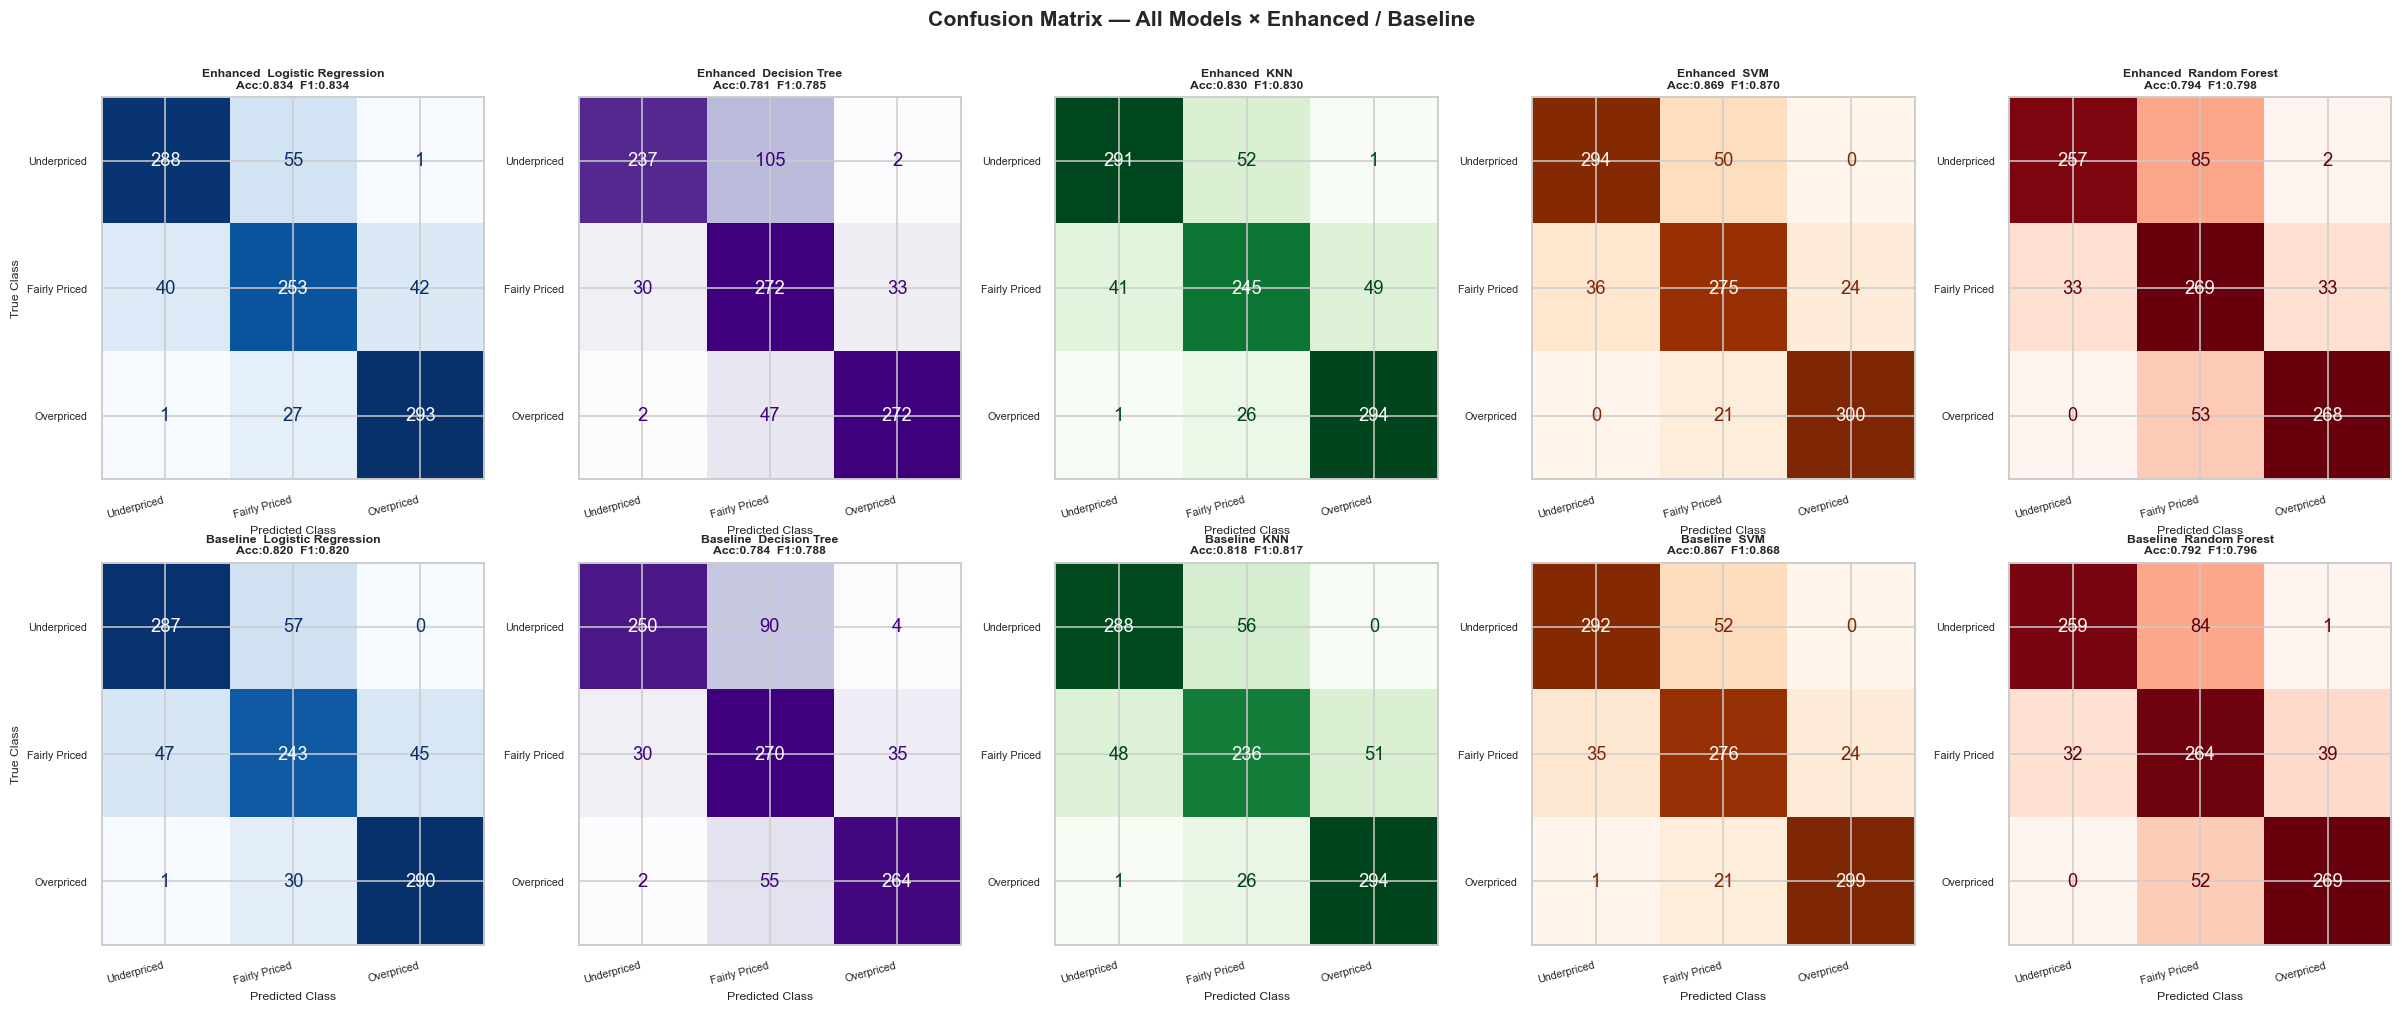

In [ ]:
cmaps = ['Blues','Purples','Greens','Oranges','Reds']
fig, axes = plt.subplots(2, 5, figsize=(22, 9))

for row_idx, (preds, version) in enumerate([(preds_A,"Enhanced"),(preds_B,"Baseline")]):
    for col_idx, (model_name, cmap) in enumerate(zip(model_names_list, cmaps)):
        ax = axes[row_idx][col_idx]
        ConfusionMatrixDisplay.from_predictions(
            y_test_cls,
            preds[model_name]['y_pred'],
            labels=[0,1,2],
            display_labels=CLASS_NAMES,
            cmap=cmap,
            ax=ax,
            colorbar=False
)
        acc = preds[model_name]['test_acc']
        f1  = preds[model_name]['test_f1']
        ax.set_title(f"{version}  {model_name}\nAcc:{acc:.3f}  F1:{f1:.3f}",
                     fontsize=8, fontweight='bold')
        ax.set_xlabel("Predicted Class",  fontsize=8)
        ax.set_ylabel("True Class" if col_idx==0 else "",  fontsize=8)
        ax.set_xticklabels(CLASS_NAMES, rotation=15, ha='right', fontsize=7)
        ax.set_yticklabels(CLASS_NAMES, fontsize=7)

plt.suptitle("Confusion Matrix — All Models × Enhanced / Baseline",
              fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Step 9. 성능 비교 시각화

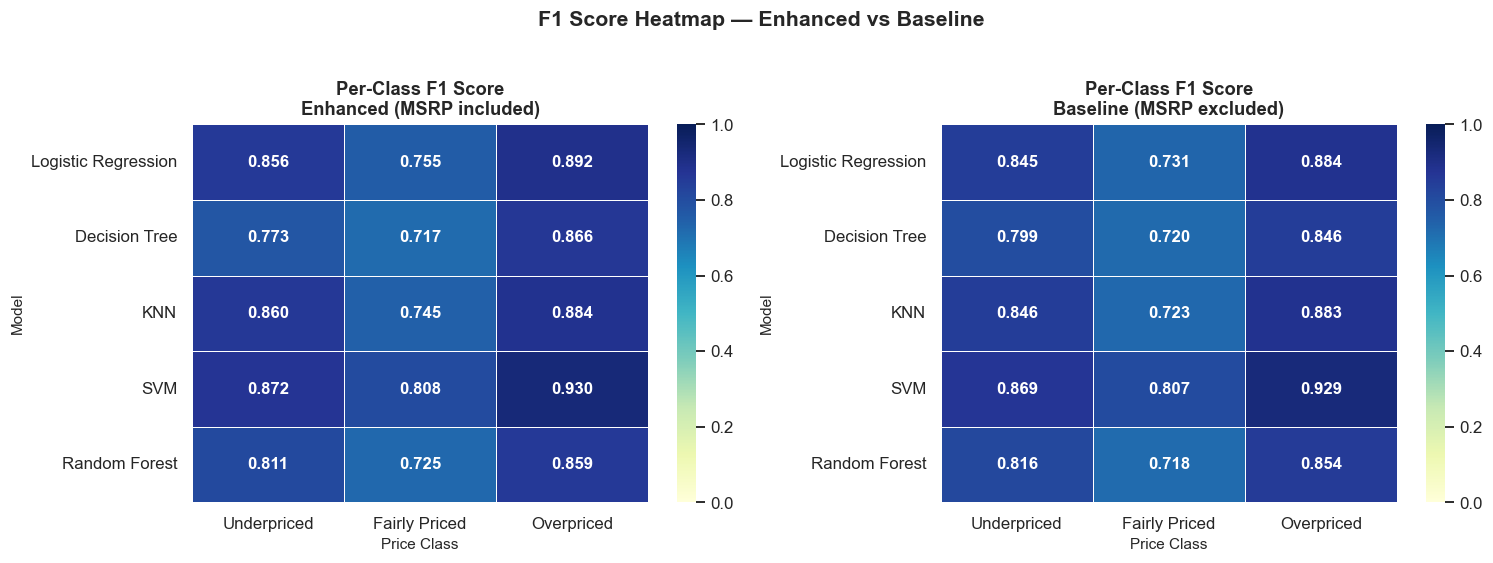

In [ ]:
# ── (A) Per-class F1 Heatmap ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (preds, version, color) in zip(axes, [
    (preds_A, "Enhanced (MSRP included)", COLOR_ENH),
    (preds_B, "Baseline (MSRP excluded)", COLOR_BASE),
]):
    f1_mat = np.array([
        f1_score(y_test_cls, preds[m]['y_pred'], average=None, labels=[0,1,2])
        for m in model_names_list
    ])
    f1_df = pd.DataFrame(f1_mat, index=model_names_list, columns=CLASS_NAMES)
    sns.heatmap(f1_df, annot=True, fmt='.3f', cmap='YlGnBu',
                vmin=0, vmax=1, linewidths=0.5, ax=ax,
                annot_kws={'size':11, 'weight':'bold'})
    ax.set_title(f"Per-Class F1 Score\n{version}",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Price Class",  fontsize=10)
    ax.set_ylabel("Model", fontsize=10)

plt.suptitle("F1 Score Heatmap — Enhanced vs Baseline",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


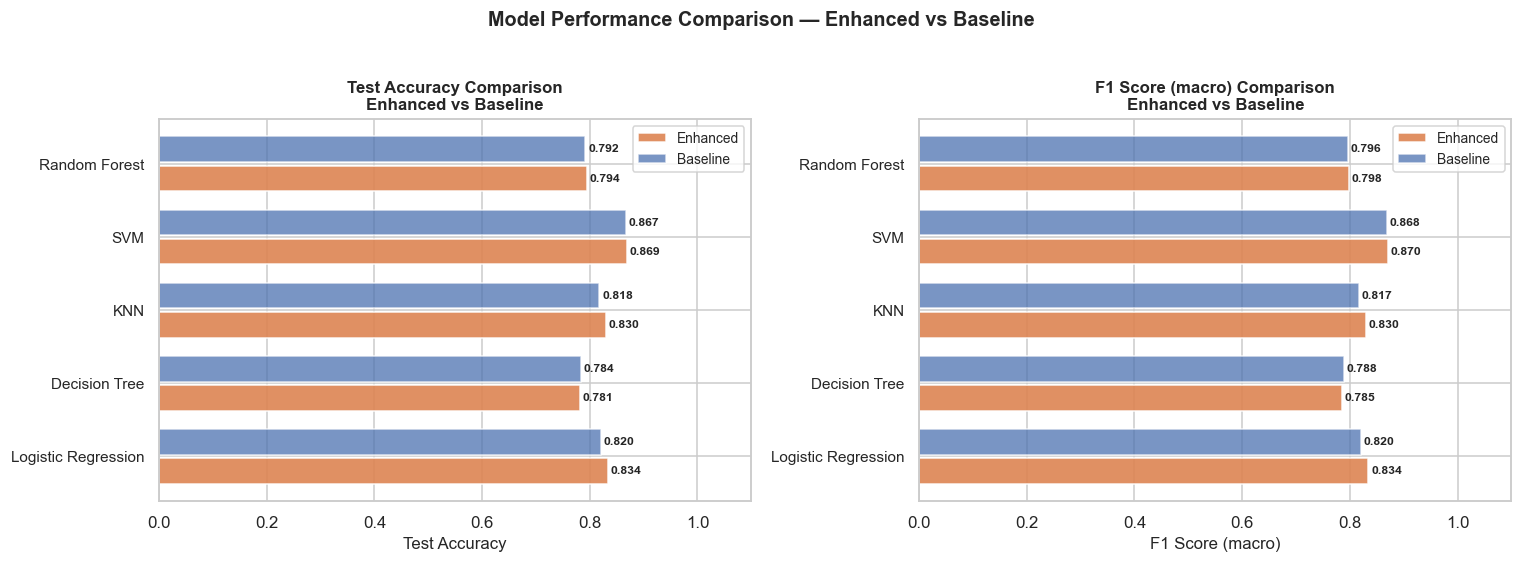

In [ ]:
# ── (B) Test Accuracy / F1 macro Horizontal Bar ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ['test_acc', 'test_f1']):
    title = 'Test Accuracy' if metric=='test_acc' else 'F1 Score (macro)'
    vals_A = [preds_A[m][metric] for m in model_names_list]
    vals_B = [preds_B[m][metric] for m in model_names_list]
    y_pos  = np.arange(len(model_names_list))
    ax.barh(y_pos-0.2, vals_A, 0.35, color=COLOR_ENH, alpha=0.9, label='Enhanced')
    ax.barh(y_pos+0.2, vals_B, 0.35, color=COLOR_BASE, alpha=0.75, label='Baseline')
    ax.set_yticks(y_pos); ax.set_yticklabels(model_names_list,fontsize=10)
    ax.set_xlim(0, 1.1); ax.set_xlabel(title, fontsize=11)
    ax.set_title(f"{title} Comparison\nEnhanced vs Baseline",
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    for i, (a, b) in enumerate(zip(vals_A, vals_B)):
        ax.text(a+0.005, i-0.2, f'{a:.3f}', va='center', fontsize=8, fontweight='bold')
        ax.text(b+0.005, i+0.2, f'{b:.3f}', va='center', fontsize=8, fontweight='bold')

plt.suptitle("Model Performance Comparison — Enhanced vs Baseline",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


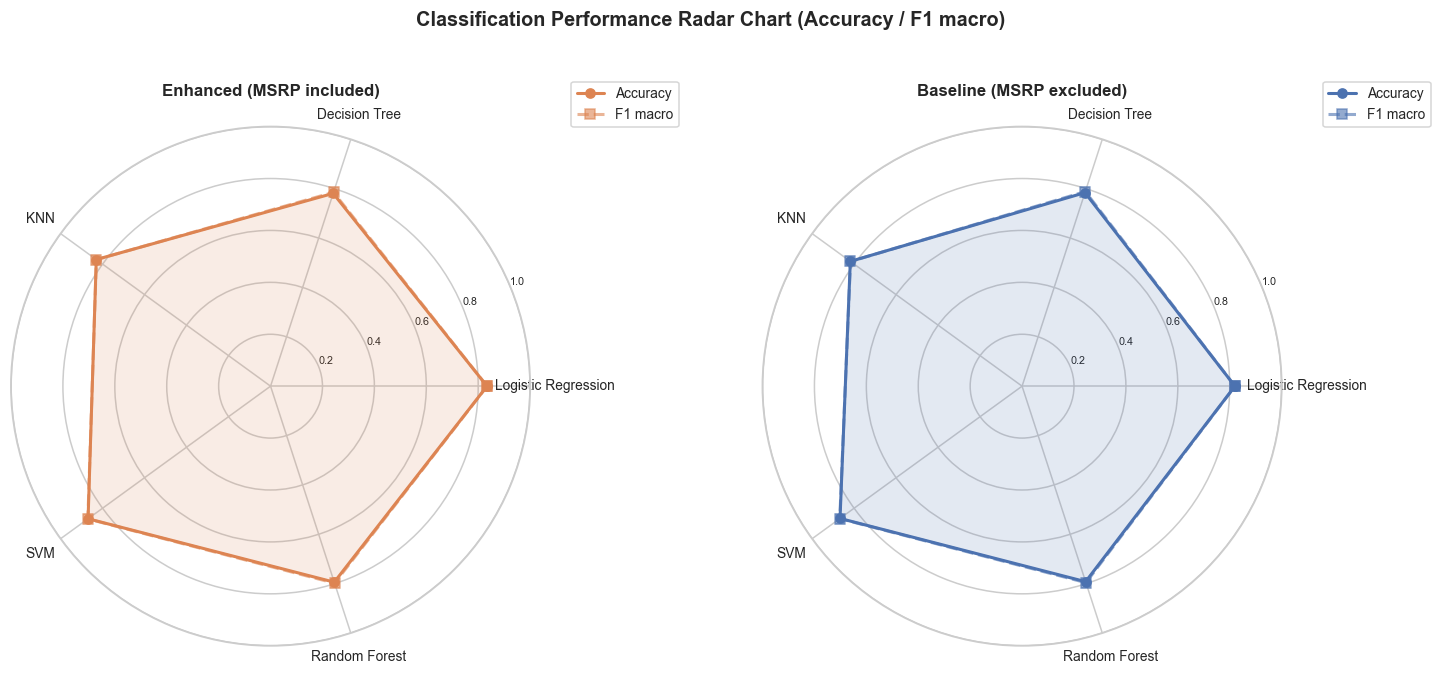

In [ ]:
# ── (C) Radar Chart (5 models) ───────────────────────
angles = np.linspace(0, 2*np.pi, len(model_names_list), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          subplot_kw=dict(polar=True))

for ax, (preds, version, color) in zip(axes, [
    (preds_A, "Enhanced (MSRP included)", COLOR_ENH),
    (preds_B, "Baseline (MSRP excluded)", COLOR_BASE),
]):
    acc_vals = [preds[m]['test_acc'] for m in model_names_list] + [preds[model_names_list[0]]['test_acc']]
    f1_vals  = [preds[m]['test_f1']  for m in model_names_list] + [preds[model_names_list[0]]['test_f1']]

    ax.plot(angles, acc_vals, 'o-', color=color, linewidth=2, label='Accuracy')
    ax.fill(angles, acc_vals, color=color, alpha=0.1)
    ax.plot(angles, f1_vals,  's--', color=color, linewidth=2, alpha=0.6, label='F1 macro')
    ax.fill(angles, f1_vals, color=color, alpha=0.05)

    ax.set_thetagrids(np.degrees(angles[:-1]), model_names_list,
                      fontsize=9)
    ax.set_ylim(0, 1); ax.set_yticks([0.2,0.4,0.6,0.8,1.0])
    ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7)
    ax.set_title(version, fontsize=11,
                 fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1), fontsize=9)

plt.suptitle("Classification Performance Radar Chart (Accuracy / F1 macro)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


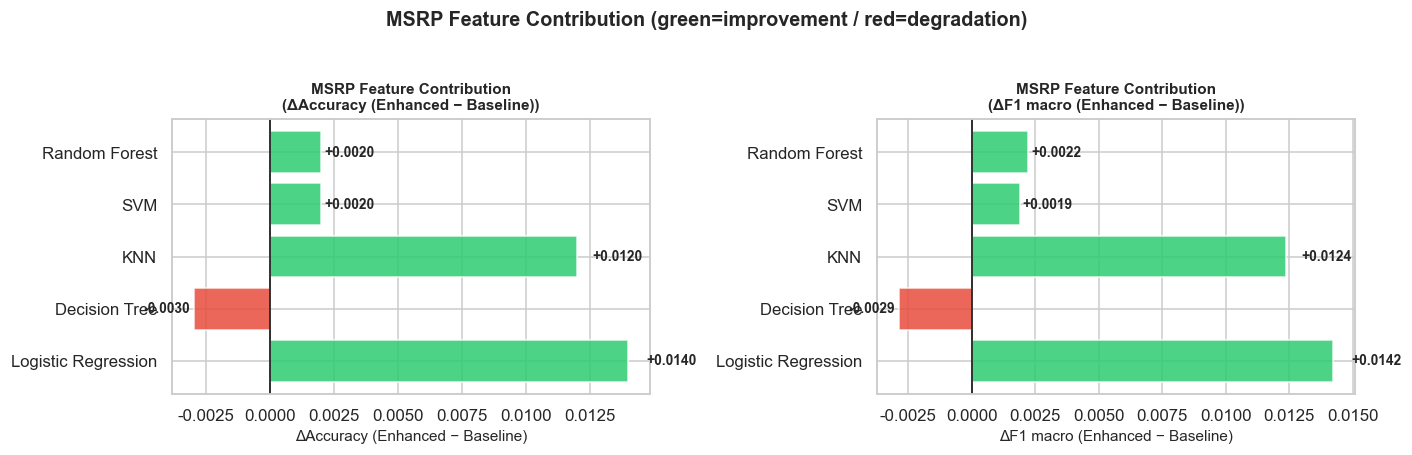

In [ ]:
# ── (D) MSRP Contribution Delta (A − B) ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (metric, xlabel) in zip(axes, [
    ('test_acc', 'ΔAccuracy (Enhanced − Baseline)'),
    ('test_f1',  'ΔF1 macro (Enhanced − Baseline)'),
]):
    delta = {m: preds_A[m][metric] - preds_B[m][metric]
             for m in model_names_list}
    colors_d = ['#2ecc71' if v>=0 else '#e74c3c' for v in delta.values()]
    ax.barh(list(delta.keys()), list(delta.values()),
            color=colors_d, alpha=0.85)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(f"MSRP Feature Contribution\n({xlabel})",
                 fontsize=10, fontweight='bold')
    for i, v in enumerate(delta.values()):
        off = abs(v)*0.05 if v!=0 else 1e-4
        ax.text(v+(off if v>=0 else -off), i, f'{v:+.4f}',
                va='center', ha='left' if v>=0 else 'right',
                fontsize=9, fontweight='bold')

plt.suptitle("MSRP Feature Contribution (green=improvement / red=degradation)",
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


## Step 10. 전체 모델 성능 요약 테이블

In [ ]:
rows = []
for version, preds, cv_res in [
    ('Enhanced', preds_A, cv_results_A),
    ('Baseline', preds_B, cv_results_B),
]:
    for m in model_names_list:
        y_pred = preds[m]['y_pred']
        rec_u  = recall_score(y_test_cls, y_pred, labels=[0], average='macro', zero_division=0)
        rec_f  = recall_score(y_test_cls, y_pred, labels=[1], average='macro', zero_division=0)
        rec_o  = recall_score(y_test_cls, y_pred, labels=[2], average='macro', zero_division=0)
        rows.append({
            'Version':          version,
            'Model':              m,
            'Best Param':       f"{cv_res[m]['param_name']}={cv_res[m]['best_param']}",
            'CV F1 macro':      cv_res[m]['best_cv'],
            'Test Accuracy':    preds[m]['test_acc'],
            'Test F1 macro':    preds[m]['test_f1'],
            'Recall_Underpriced': rec_u,
            'Recall_FairlyPriced': rec_f,
            'Recall_Overpriced':   rec_o,
        })

summary_df = pd.DataFrame(rows)

def highlight_ver(row):
    c = "#3746A7" if row['Version']=='Enhanced' else '#d6eaf8'
    return [f'background-color: {c}'] * len(row)

display(summary_df.style
    .set_caption("Classification Full Model Performance Summary")
    .apply(highlight_ver, axis=1)
    .format({c: '{:.4f}' for c in summary_df.columns
             if summary_df[c].dtype == float})
    .background_gradient(cmap='YlGnBu',
                         subset=['Test F1 macro',
                                 'Recall_Underpriced','Recall_Overpriced'])
    .set_properties(**{'text-align':'center','font-size':'10.5pt'})
    .set_table_styles([{'selector':'caption',
                        'props':[('font-size','13pt'),
                                 ('font-weight','bold'),
                                 ('text-align','left')]}])
)


,Version,Model,Best Param,CV F1 macro,Test Accuracy,Test F1 macro,Recall_Underpriced,Recall_FairlyPriced,Recall_Overpriced
0,Enhanced,Logistic Regression,C=100,0.8490,0.8340,0.8343,0.8372,0.7552,0.9128
1,Enhanced,Decision Tree,max_depth=7,0.8421,0.7810,0.7854,0.6890,0.8119,0.8474
2,Enhanced,KNN,k=15,0.8308,0.8300,0.8295,0.8459,0.7313,0.9159
3,Enhanced,SVM,C=10,0.8776,0.8690,0.8701,0.8547,0.8209,0.9346
4,Enhanced,Random Forest,n_estimators=200,0.8550,0.7940,0.7983,0.7471,0.8030,0.8349
5,Baseline,Logistic Regression,C=100,0.8270,0.8200,0.8201,0.8343,0.7254,0.9034
6,Baseline,Decision Tree,max_depth=10,0.8414,0.7840,0.7883,0.7267,0.8060,0.8224
7,Baseline,KNN,k=15,0.8203,0.8180,0.8172,0.8372,0.7045,0.9159
8,Baseline,SVM,C=10,0.8541,0.8670,0.8682,0.8488,0.8239,0.9315
9,Baseline,Random Forest,n_estimators=200,0.8478,0.7920,0.7960,0.7529,0.7881,0.8380


## Step 11. 최종 결론